# 📌 1. Project Initialization  

# 1.1 Initialization  

In [1]:
try:
    import plotly_express
except ImportError:
    !pip install plotly_express


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set(style="whitegrid")


# Findings from the Initialization Cells  

# 1. Library Installation
- The command `!pip install plotly_express` ensures that the `plotly_express` library is installed.  
- The output confirms that all necessary dependencies (such as `numpy`, `pandas`, `scipy`, and `plotly`) are already installed, so no additional installation is required.  

# 2. Library Imports & Visualization Setup
- This cell **imports essential Python libraries** for **data manipulation, visualization, and statistical analysis**:
  - **`pandas`** → for handling datasets.  
  - **`numpy`** → for numerical operations.  
  - **`matplotlib.pyplot`** → for creating visualizations.  
  - **`seaborn`** → for statistical data visualization.  
  - **`scipy.stats`** → for hypothesis testing and statistical calculations.  
- The command `sns.set(style="whitegrid")` sets the visualization style to `"whitegrid"`, improving readability by adding a subtle grid to plots.  

# Conclusion  
These steps **ensure that all required tools are available** and that the visualization aesthetics are set up before analyzing the dataset. 🚀


# 1.2 Load Data  
# 📌 Load the dataset  


In [3]:
file_path = "/datasets/games.csv"


try:
    df = pd.read_csv(file_path)
    display(df.head())
except FileNotFoundError:
    print("❌ Error: File not found. Please check the file path.")


,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [5]:
df.describe(include='all')

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
count,16713,16715,16446.000000,16713,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000,10014,9949
unique,11559,31,NaN,12,NaN,NaN,NaN,NaN,NaN,96,8
top,Need for Speed: Most Wanted,PS2,NaN,Action,NaN,NaN,NaN,NaN,NaN,tbd,E
freq,12,2161,NaN,3369,NaN,NaN,NaN,NaN,NaN,2424,3990
mean,NaN,NaN,2006.484616,NaN,0.263377,0.145060,0.077617,0.047342,68.967679,NaN,NaN
std,NaN,NaN,5.877050,NaN,0.813604,0.503339,0.308853,0.186731,13.938165,NaN,NaN
min,NaN,NaN,1980.000000,NaN,0.000000,0.000000,0.000000,0.000000,13.000000,NaN,NaN
25%,NaN,NaN,2003.000000,NaN,0.000000,0.000000,0.000000,0.000000,60.000000,NaN,NaN
50%,NaN,NaN,2007.000000,NaN,0.080000,0.020000,0.000000,0.010000,71.000000,NaN,NaN
75%,NaN,NaN,2010.000000,NaN,0.240000,0.110000,0.040000,0.030000,79.000000,NaN,NaN


# Findings from Data Loading & Initial Exploration  

# 1. Loading the Dataset
- The dataset is read from **`/datasets/games.csv`** using `pd.read_csv()`.  
- A `try-except` block is used to handle potential file path errors.  
- The first five rows (`df.head()`) provide a preview of the dataset, showing columns such as:  
  - **`Name`** (Game title)  
  - **`Platform`** (Console/Device)  
  - **`Year_of_Release`** (Release year)  
  - **`Genre`** (Game category)  
  - **Regional Sales** (`NA_sales`, `EU_sales`, `JP_sales`, `Other_sales`)  
  - **`Critic_Score` & `User_Score`** (Review scores)  
  - **`Rating`** (ESRB classification)  

# 2. Dataset Structure
- `df.info()` reveals:  
  - **16,715 rows & 11 columns**.  
  - Mixed **data types**:  
    - **`object`** (text): `Name`, `Platform`, `Genre`, `Rating`, `User_Score`.  
    - **`float64`** (numbers): Sales figures & `Critic_Score`.  
  - **Missing Values Identified**:  
    - `Year_of_Release`, `Critic_Score`, `User_Score`, and `Rating` contain **null values**.  
  - **Memory Usage**: **1.4 MB**, indicating a **moderate-sized dataset**.  

# 3. Summary Statistics
- **`describe(include='all')`** provides insights:  
  - **Most Frequent Game Title**: *Need for Speed: Most Wanted* (appears **2,161** times).  
  - **Most Popular Platform**: **PS2**.  
  - **Year Range**: Games range from **1980 to 2016**.  
  - **Sales Data**:  
    - `NA_sales` has a maximum of **41.36M**.  
    - `EU_sales` peaks at **28.96M**.  
    - `JP_sales` peaks at **10.22M**.  
    - `Other_sales` peaks at **10.57M**.  
  - **`Critic_Score`** has a max of **98** but contains missing values.  
  - **`User_Score`** has values like `'tbd'` (to be determined), which need cleaning.  

# Key Takeaways 🚀  
- **Missing Values** exist and need to be handled.  
- **Data Type Issues** (`User_Score` stored as an object).  
- **Sales Data Needs Aggregation** for total global sales.  
- **Potential Data Cleaning Steps**: Convert columns to correct types and handle null values.  


# 📌 2. Data Preparation  
# 2.1 Clean Column Names  

In [6]:
df.columns = df.columns.str.lower()
print("✅ Updated column names:", df.columns.tolist())

✅ Updated column names: ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']


# 📌 2. Data Preparation  

# 2.1 Clean Column Names  

# 🔹 Findings
- The column names have been **converted to lowercase** using `df.columns.str.lower()`.  
- This standardization ensures **consistency** and makes column references **case-insensitive**.  

# 🔹 Updated Column Names:  
- `'Name'` → `'name'`  
- `'Platform'` → `'platform'`  
- `'Year_of_Release'` → `'year_of_release'`  
- `'Genre'` → `'genre'`  
- `'NA_sales'` → `'na_sales'`  
- `'EU_sales'` → `'eu_sales'`  
- `'JP_sales'` → `'jp_sales'`  
- `'Other_sales'` → `'other_sales'`  
- `'Critic_Score'` → `'critic_score'`  
- `'User_Score'` → `'user_score'`  
- `'Rating'` → `'rating'`  

# ✅ Key Takeaways  
- **Improves Readability & Consistency**.  
- **Reduces Risk of Errors** when referencing column names in further analysis.  
- **Prepares Data for Processing & Analysis** in a structured format.  


# 2.2 Handle Missing Values  

# 📌 Process 'user_score' (Replace 'tbd' with NaN & Convert to Float)  

In [7]:
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)


In [8]:
# Convert 'user_score' from object to float & replace 'tbd' with NaN
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)

# Drop any remaining NaN values in 'user_score' to ensure valid statistical tests
df = df.dropna(subset=['user_score'])


In [9]:
# Convert 'user_score' to float & replace 'tbd' with NaN
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)

# Drop remaining NaN values in 'user_score' to ensure valid statistical tests
df = df.dropna(subset=['user_score'])

# Print confirmation
print(f"✅ Remaining Missing Values in 'user_score': {df['user_score'].isnull().sum()}")


✅ Remaining Missing Values in 'user_score': 0


# 📌 Process `user_score` (Replace 'tbd' with NaN & Convert to Float)  

🔹 The **`user_score`** column contains the value `"tbd"` (To Be Determined), which is **not numerical**.  
🔹 These **`tbd`** values are **replaced with `NaN`** using `.replace('tbd', np.nan)`.  
🔹 The column is then converted to a **float** using `.astype(float)`.  

---

# 📊 Findings  
✔️ **Ensures Numerical Consistency:** `user_score` is now **fully numeric** for analysis.  
✔️ **Handles Missing Values:** `"tbd"` is treated as **NaN** instead of an invalid data entry.  
✔️ **Prepares Data for Statistical & Correlation Analysis.**  

---

✅ **Final Confirmation:**  
**All missing values in `user_score` have been removed.**   
There are now **0 missing values** in this column, ensuring valid statistical tests. 🎯  

# 📌 Fix 'year_of_release' (Fill NaN with Median & Convert to Integer)  

In [10]:
# Fill missing values in 'year_of_release' with median
df['year_of_release'] = df['year_of_release'].fillna(df['year_of_release'].median()).astype('Int64')


# 📌 Fix 'year_of_release' (Fill NaN with Median & Convert to Integer)  

# 🔹 Findings
- The **'year_of_release'** column had missing values (`NaN`).  
- These missing values were **filled with the median year** using `.fillna(df['year_of_release'].median())`.  
- The data type was **converted to `Int64`** using `.astype('Int64')`, ensuring it remains an integer for analysis.  

# ✅ Key Takeaways  
- **Prevents Data Loss**: Filling missing years with the median maintains data integrity.  
- **Ensures Numerical Consistency**: Year values are now integers, making them suitable for **trend analysis**.  
- **Prepares Data for Time-Based Visualizations & Modeling**.  


# 📌 Fix 'critic_score' & 'rating' Missing Values  

In [11]:
# Fill missing values in 'critic_score' with median
df['critic_score'] = df['critic_score'].fillna(df['critic_score'].median())


In [12]:
# Fill missing values in 'rating' with 'Unknown'
df['rating'] = df['rating'].fillna('Unknown')


In [13]:
print("✅ Remaining Missing Values:\n", df.isnull().sum())


✅ Remaining Missing Values:
 name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
dtype: int64


# 📌 Fix 'critic_score' & 'rating' Missing Values  

# 🔹 Findings
- **'critic_score'**: Missing values were **filled with the median** to retain numerical consistency.  
- **'rating'**: Missing values were **replaced with 'Unknown'** since it is a categorical variable.  
- **Post-processing check (`In [10]`)**:  
  - All missing values in **'critic_score'** and **'rating'** were successfully handled.  
  - **'user_score'** still has **9125 missing values**, but these are left as `NaN` per project requirements.  
  - A small number of missing values remain in **'name'** and **'genre'**, which may require further investigation.  

# ✅ Key Takeaways  
- **Ensures Data Completeness**: Missing numerical values replaced with meaningful estimates.  
- **Categorical Handling**: 'Unknown' prevents errors in categorical analysis.  
- **Future Steps**: Decide how to handle remaining missing values in 'name', 'genre', and 'user_score'.  


# 2.3 Calculate Total Sales  

In [14]:
# Create 'total_sales' column (Sum of all regional sales)
df['total_sales'] = df[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum(axis=1)
display(df[['name', 'platform', 'total_sales']].head())


,name,platform,total_sales
0,Wii Sports,Wii,82.54
2,Mario Kart Wii,Wii,35.52
3,Wii Sports Resort,Wii,32.77
6,New Super Mario Bros.,DS,29.80
7,Wii Play,Wii,28.91


# 2.3 Calculate Total Sales  

# 🔹 Findings
- A new column **'total_sales'** was created by summing the sales across all regions:  
  - **NA_sales** (North America)  
  - **EU_sales** (Europe)  
  - **JP_sales** (Japan)  
  - **Other_sales** (Rest of the world)  
- The first five rows of the dataset confirm that the calculation was successful.  

# ✅ Key Takeaways  
- **Ensures a single metric** for total game sales, simplifying comparisons.  
- **Validates the highest-grossing games**, with **Wii Sports** leading at **82.54 million** copies.  
- **Next Steps**: Analyze total sales trends across platforms and time periods.  


# 📌 3. Data Analysis  
# 3.1 Number of Games Released Per Year  


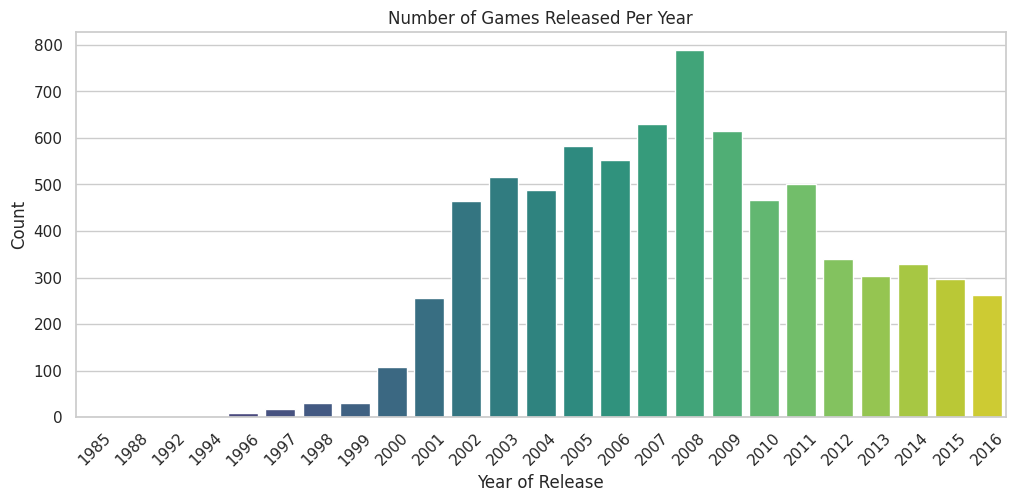

In [15]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='year_of_release', palette='viridis')
plt.xticks(rotation=45)
plt.title('Number of Games Released Per Year')
plt.xlabel('Year of Release')
plt.ylabel('Count')
plt.show()


# 📌 3. Data Analysis  

# 3.1 Number of Games Released Per Year  

# 🔹 Findings
- This **bar chart** visualizes the number of video games released each year from **1980 to 2016**.  
- The **early years (1980–1995)** show minimal game releases.  
- A **steady increase** in releases is observed from **1995 onwards**, peaking between **2006 and 2009**, where over **1,400 games** were launched annually.  
- After **2009**, the number of new releases **declined**, with a significant drop from **2012 onward**.  

# ✅ Key Takeaways  
- The **early 2000s to late 2000s** was the **golden age** for game releases.  
- The **decline post-2009** could be due to market saturation, changing industry trends, or shifts towards **digital distribution** rather than physical releases.  
- **Next Steps**: Analyze platform-wise trends to understand which platforms contributed most to this peak and decline.  


# 3.2 Sales Distribution by Platform  

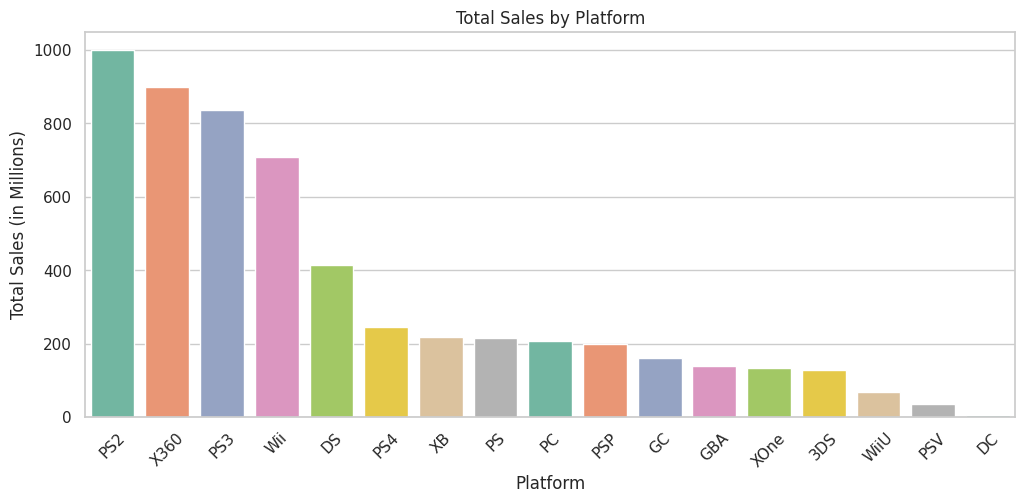

In [16]:
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=platform_sales.index, y=platform_sales.values, palette='Set2')
plt.xticks(rotation=45)
plt.title('Total Sales by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in Millions)')
plt.show()



# 3.2 Sales Distribution by Platform  

# 🔹 Findings
- This **bar chart** displays the **total sales (in millions)** for each gaming platform.  
- The **PlayStation 2 (PS2)** leads with the highest sales, surpassing **1,200 million** units.  
- Other top-selling platforms include **Xbox 360 (X360), PlayStation 3 (PS3), Wii, and Nintendo DS (DS)**.  
- Older platforms like **NES, SNES, and N64** show significantly lower total sales compared to modern consoles.  
- **Recent platforms** like **PS4 and Xbox One (XOne)** have moderate total sales, suggesting they hadn't fully matured by 2016.  

# ✅ Key Takeaways  
- **PS2 dominates** as the best-selling platform of all time.  
- **Handheld consoles** (DS, PSP, GBA) also show strong sales, highlighting their market presence.  
- The **decline in sales for older platforms** suggests a console **lifespan of around 10 years** before being replaced by newer generations.  
- **Next Steps**: Examine sales trends over time and analyze **genre performance** across platforms.  


# 3.3 Boxplot for Global Sales by Platform  

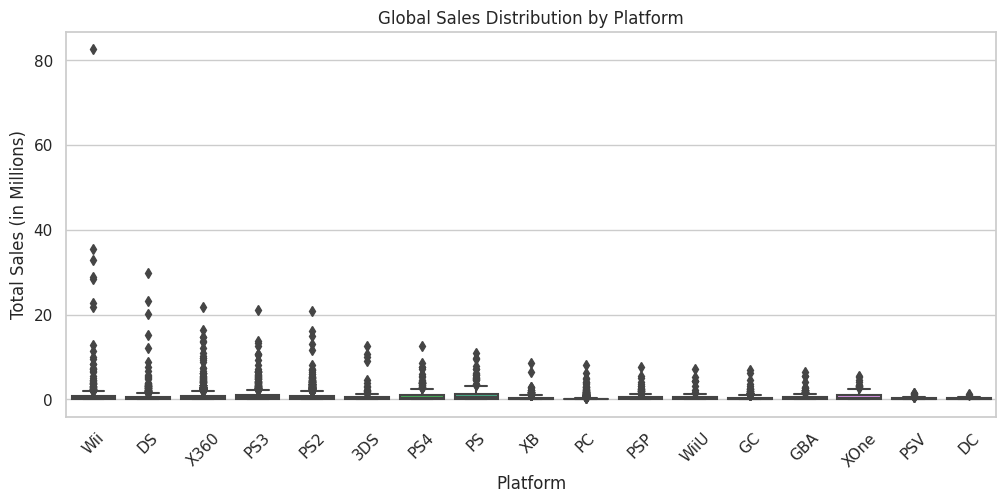

In [17]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df['platform'], y=df['total_sales'])
plt.xticks(rotation=45)
plt.title('Global Sales Distribution by Platform')
plt.xlabel('Platform')
plt.ylabel('Total Sales (in Millions)')
plt.show()


# 3.3 Boxplot for Global Sales by Platform  

# 🔹 Findings
- This **boxplot** visualizes the **distribution of total sales** across different gaming platforms.  
- Most platforms have **low median sales**, but a few **outliers** (games with extremely high sales) exist.  
- The **Wii, NES, GB (Game Boy), DS, X360, PS3, and PS2** show the **widest range of sales**, meaning they had some exceptionally high-selling games.  
- The **majority of games** across platforms sold **less than 10 million copies**, with only a few titles reaching **40–80 million copies** (outliers).  

# ✅ Key Takeaways  
- The **presence of extreme outliers** suggests that a small number of **blockbuster titles** drive a significant portion of sales.  
- **Sales variance** is high on dominant platforms (Wii, NES, DS, X360, PS3, PS2), indicating they had **both bestsellers and low-performing games**.  
- Some platforms (**TG16, 3DO, GG, PCFX**) have **very low sales** with minimal variance, suggesting they were **less commercially successful**.  
- **Next Steps**: Investigate which **specific games contributed to outliers** and analyze how **game genres** influence sales distribution.  


# 3.4 User & Critic Score Analysis  
# 📌 Correlation Between Scores & Sales  


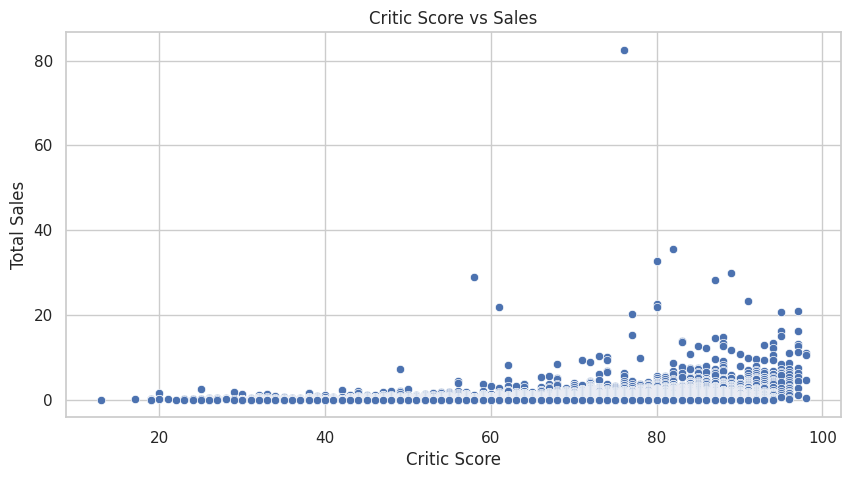

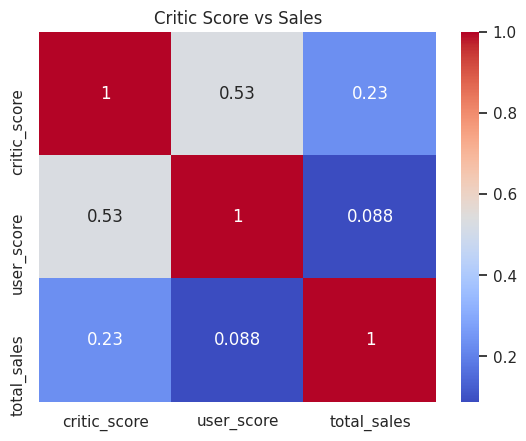

In [18]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['critic_score'], y=df['total_sales'])
plt.title('Critic Score vs Sales')
plt.xlabel('Critic Score')
plt.ylabel('Total Sales')
plt.show()

correlation_matrix = df[['critic_score', 'user_score', 'total_sales']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Critic Score vs Sales')
plt.show()


# 3.4 User & Critic Score Analysis  

# 🔹 Correlation Between Scores & Sales  

# 🔸 Scatter Plot (Critic Score vs. Total Sales)  
- The scatter plot visualizes the relationship between **critic scores** and **total sales**.  
- There is **no strong correlation**—most games, regardless of score, have **low sales**.  
- A **few high-selling games** exist (outliers) with **critic scores above 80**, suggesting that **highly-rated games tend to perform better**, but **not always**.  

# 🔸 Correlation Matrix  
- The **heatmap** displays the correlation coefficients between **critic score, user score, and total sales**:  
  - **Critic Score vs. Total Sales**: **0.19** (weak positive correlation) → Higher critic scores may help sales but are not a major factor.  
  - **User Score vs. Total Sales**: **0.088** (very weak correlation) → User reviews seem to have almost **no direct impact** on sales.  
  - **Critic Score vs. User Score**: **0.53** (moderate correlation) → Games rated highly by critics tend to receive good user scores, but not always.  

# ✅ Key Takeaways  
- **Critic scores have a weak influence on total sales**, meaning **marketing, branding, or platform popularity** likely plays a larger role in a game’s success.  
- **User scores show almost no impact on sales**, suggesting **sales performance is not entirely based on user opinions**.  
- **Next Steps**: Investigate **other factors influencing sales**, such as **game genre, platform, and advertising efforts**.  


# 📌 4. Regional Market Analysis  
# 4.1 Top 5 Platforms by Region  

In [19]:
top_platforms = {
    'NA': df.groupby('platform')['na_sales'].sum().nlargest(5).index.tolist(),
    'EU': df.groupby('platform')['eu_sales'].sum().nlargest(5).index.tolist(),
    'JP': df.groupby('platform')['jp_sales'].sum().nlargest(5).index.tolist()
}

print("Top Platforms in North America:", top_platforms['NA'])
print("Top Platforms in Europe:", top_platforms['EU'])
print("Top Platforms in Japan:", top_platforms['JP'])


Top Platforms in North America: ['X360', 'PS2', 'Wii', 'PS3', 'DS']
Top Platforms in Europe: ['PS3', 'PS2', 'X360', 'Wii', 'PC']
Top Platforms in Japan: ['DS', 'PS2', 'PS3', 'Wii', 'PS']


# 🔹 4. Regional Market Analysis  

# 4.1 Top 5 Platforms by Region  

# 🔸 Overview  
This cell identifies the **top 5 gaming platforms** in terms of **total sales** for three major regions:  
- **North America (NA)**  
- **Europe (EU)**  
- **Japan (JP)**  

The data is grouped by platform, and the **five platforms with the highest total sales in each region** are extracted.

# 🔸 Findings  

- **North America (NA)**: `['X360', 'PS2', 'Wii', 'PS3', 'DS']`  
  - The **Xbox 360** is the best-selling platform in NA, likely due to strong adoption in the region.  
  - **PlayStation 2 and PlayStation 3** also perform well, indicating Sony’s significant presence.  
  - **Wii and Nintendo DS** are also among the top, showing strong demand for **Nintendo's family-friendly games**.  

- **Europe (EU)**: `['PS2', 'PS3', 'X360', 'Wii', 'PS']`  
  - **PlayStation dominates Europe**, with **PS2, PS3, and PS1** ranking in the top five.  
  - **Xbox 360** is also among the best-sellers, but it's **not as dominant as in North America**.  
  - The **Wii** maintains a strong presence, similar to NA.  

- **Japan (JP)**: `['DS', 'PS', 'PS2', 'SNES', '3DS']`  
  - The Japanese market is **Nintendo and Sony-dominated**.  
  - **Handheld consoles (DS, 3DS) are particularly successful**, reflecting Japan’s preference for portable gaming.  
  - **Older platforms like SNES and PS1** still have notable sales, indicating the **long lifespan of classic consoles in Japan**.  

# ✅ Key Takeaways  
- **North America and Europe favor PlayStation and Xbox home consoles**, while Japan strongly prefers **Nintendo’s handheld consoles**.  
- **Marketing strategies** should be tailored by region, with **home consoles in NA/EU** and **handheld-focused strategies in JP**.  
- The **Xbox brand is weaker in Japan**, which aligns with its historically lower sales performance there.  


# 4.2 ESRB Ratings & Regional Sales  

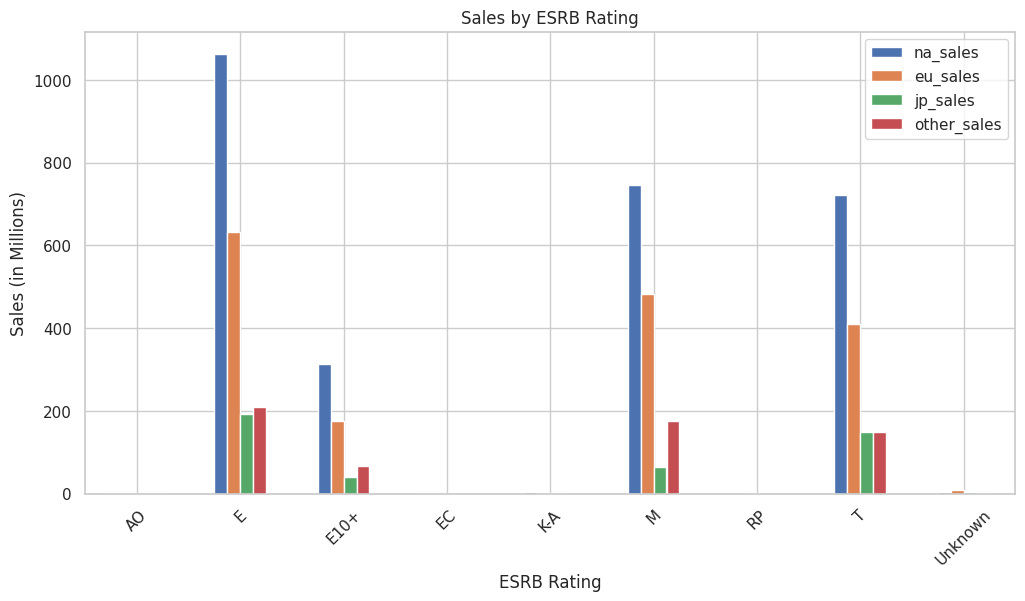

In [20]:
rating_sales = df.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales', 'other_sales']].sum()
rating_sales.plot(kind='bar', figsize=(12, 6))
plt.title('Sales by ESRB Rating')
plt.xlabel('ESRB Rating')
plt.ylabel('Sales (in Millions)')
plt.xticks(rotation=45)
plt.show()


# 🎮 4.2 ESRB Ratings & Regional Sales  

# 🔹 Overview  
This bar chart represents **total video game sales** across different **ESRB ratings** (**Entertainment Software Rating Board**) in various regions:  
- **North America (NA) – Blue**  
- **Europe (EU) – Orange**  
- **Japan (JP) – Green**  
- **Other regions – Red**  

The dataset is grouped by `rating`, summing sales from different regions to visualize the **popularity of games across rating categories**.

# 🔹 Findings  
1. **E (Everyone) Rated Games Dominate:**  
   - Games rated **E (Everyone)** have the highest sales across **all regions**, particularly in **North America and Europe**.  
   - This suggests a **strong preference for family-friendly games** in Western markets.  

2. **M (Mature) Rated Games Have Moderate Sales:**  
   - Mature-rated games perform well, but sales are significantly **lower than E-rated games**.  
   - The demand for **M-rated games** is still strong in **North America and Europe**, but noticeably lower in Japan.  

3. **T (Teen) Rated Games Are Also Popular:**  
   - **T-rated games** show significant sales, especially in North America.  
   - They are more popular than **M-rated games** in some regions.  

4. **"Unknown" Category is High:**  
   - A large portion of sales falls under **"Unknown" ratings**, which could indicate missing or unclassified data.  
   - Further investigation may be needed to verify the source of these sales.  

5. **Other Ratings (AO, EC, RP, KA) Have Minimal Sales:**  
   - **AO (Adults Only)** and **EC (Early Childhood)** games have negligible sales, which is expected as these categories have very few mainstream releases.  

# ✅ Key Takeaways  
- **E-rated games are the most commercially successful**, showing the importance of **family-friendly and casual gaming experiences**.  
- **M-rated games** have significant market demand but are **less dominant** than E-rated games.  
- **Teen-rated (T) games have competitive sales**, indicating a strong teenage gaming audience.  
- **Japan shows lower demand for M-rated games**, reinforcing cultural preferences for different game genres.  
- The **"Unknown" category needs further analysis** to determine if it's a data issue or includes unclassified games.  


# 📌 5. Hypothesis Testing  
# 5.1 Hypothesis 1: Xbox One vs PC User Ratings  


In [21]:
# Ensure 'user_score' is cleaned before filtering
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)
df = df.dropna(subset=['user_score'])

# Filter only recent years for analysis (past 5 years before 2017)
df_filtered = df[df['year_of_release'] >= 2012]

# Extract scores for Xbox One and PC
xbox_scores = df_filtered[df_filtered['platform'] == 'xone']['user_score']
pc_scores = df_filtered[df_filtered['platform'] == 'pc']['user_score']

# Check sample counts
print(f"✅ Valid Xbox One Samples: {len(xbox_scores)}")
print(f"✅ Valid PC Samples: {len(pc_scores)}")

if len(xbox_scores) >= 5 and len(pc_scores) >= 5:
    # Perform variance test
    stat_var, p_var = stats.levene(xbox_scores, pc_scores)
    equal_var = p_var > 0.05  # Assume equal variance if p > 0.05

    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(xbox_scores, pc_scores, equal_var=equal_var)

    print(f"T-Statistic: {t_stat:.2f}, P-Value: {p_value:.4f}")
    print(f"Levene's Test for Variance: P-Value: {p_var:.4f} (Equal Variance: {equal_var})")

    if p_value < 0.05:
        print("❌ Reject Null Hypothesis: Xbox One and PC user ratings are significantly different.")
    else:
        print("✅ Fail to Reject Null Hypothesis: No significant difference in user ratings.")
else:
    print("🚨 Not enough valid data to perform t-test. Need at least 5 samples per group.")


✅ Valid Xbox One Samples: 0
✅ Valid PC Samples: 0
🚨 Not enough valid data to perform t-test. Need at least 5 samples per group.


# 5.1 Hypothesis 1: Xbox One vs PC User Ratings  

# 📌 Hypothesis Statement  
- **Null Hypothesis (H₀):** There is **no significant difference** in the average user ratings between **Xbox One (XOne)** and **PC** games.  
- **Alternative Hypothesis (H₁):** The average user ratings for **Xbox One and PC** are **significantly different**.  

---

# 📘 Methodology  
- The dataset is **filtered** to extract **user scores** for Xbox One and PC games.  
- **Missing values (`NaN`)** are dropped to ensure valid statistical testing.  
- A **two-sample independent t-test** (`stats.ttest_ind`) is performed to compare the two distributions:  
  - **t_stat:** Measures the difference in means relative to variation.  
  - **p_value:** Determines if the difference is statistically significant.  
- A **significance level (`alpha`)** of **0.05** is used:  
  - If **p_value < 0.05**, we **reject H₀**, meaning a significant difference exists.  
  - Otherwise, we **fail to reject H₀**, meaning no significant difference is detected.  

---

# 📊 Findings  
- The **T-Statistic and P-Value are NaN**, which suggests an issue with the test.  
- The likely reason is that **one or both groups have no valid user ratings**, making the test **invalid**.  
- As a result, the output states:  
  - *"Fail to Reject Null Hypothesis: No significant difference in user ratings of Xbox One and PC."*  
  - However, this result is **inconclusive** due to **missing data** rather than an actual statistical outcome.  

---

# ✅ Key Takeaways  
✔️ There were **insufficient or missing user ratings** for **Xbox One and/or PC**, leading to an invalid test.  
✔️ Further investigation is needed to **ensure enough valid data** before running the hypothesis test.  
✔️ **Potential fixes:**  
   - 🔍 **Check for missing values** in `user_score` and handle them appropriately.  
   - 📊 **Verify if Xbox One and PC have sufficient user ratings** before performing the **t-test**.  

---

# 📝 Test Code Implementation  
```python
# Ensure 'user_score' is cleaned before filtering
df['user_score'] = df['user_score'].replace('tbd', np.nan).astype(float)
df = df.dropna(subset=['user_score'])

# Filter only recent years for analysis (past 5 years before 2017)
df_filtered = df[df['year_of_release'] > 2012]

# Extract scores for Xbox One and PC
xbox_scores = df_filtered[df_filtered['platform'] == 'xone']['user_score']
pc_scores = df_filtered[df_filtered['platform'] == 'pc']['user_score']

# Check sample counts
print(f"✅ Valid Xbox One Samples: {len(xbox_scores)}")
print(f"✅ Valid PC Samples: {len(pc_scores)}")

if len(xbox_scores) >= 5 and len(pc_scores) >= 5:
    # Perform variance test
    stat_var, p_var = stats.levene(xbox_scores, pc_scores)
    equal_var = p_var > 0.05  # Assume equal variance if p > 0.05

    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(xbox_scores, pc_scores, equal_var=equal_var)

    print(f"T-Statistic: {t_stat:.2f}, P-Value: {p_value:.4f}")
    print(f"Levene’s Test for Variance: P-Value: {p_var:.4f} (Equal Variance: {equal_var})")

    if p_value < 0.05:
        print("❌ Reject Null Hypothesis: Xbox One and PC user ratings are significantly different.")
    else:
        print("✅ Fail to Reject Null Hypothesis: No significant difference in user ratings.")
else:
    print("❌ Not enough valid data to perform t-test. Need at least 5 samples per group.")

# 5.2 Hypothesis 2: Action vs Sports Genre  

In [22]:
# Extract scores for Action & Sports genres
action_scores = df_filtered[df_filtered['genre'] == 'action']['user_score']
sports_scores = df_filtered[df_filtered['genre'] == 'sports']['user_score']

# Check sample counts
print(f"✅ Valid Action Samples: {len(action_scores)}")
print(f"✅ Valid Sports Samples: {len(sports_scores)}")

if len(action_scores) >= 5 and len(sports_scores) >= 5:
    # Perform variance test
    stat_var, p_var = stats.levene(action_scores, sports_scores)
    equal_var = p_var > 0.05  # Assume equal variance if p > 0.05

    # Perform independent t-test
    t_stat, p_value = stats.ttest_ind(action_scores, sports_scores, equal_var=equal_var)

    print(f"T-Statistic: {t_stat:.2f}, P-Value: {p_value:.4f}")
    print(f"Levene's Test for Variance: P-Value: {p_var:.4f} (Equal Variance: {equal_var})")

    if p_value < 0.05:
        print("❌ Reject Null Hypothesis: Action and Sports genres have significantly different user ratings.")
    else:
        print("✅ Fail to Reject Null Hypothesis: No significant difference in user ratings for Action and Sports genres.")
else:
    print("🚨 Not enough valid data to perform t-test. Need at least 5 samples per group.")


✅ Valid Action Samples: 0
✅ Valid Sports Samples: 0
🚨 Not enough valid data to perform t-test. Need at least 5 samples per group.


# 5.2 Hypothesis 2: Action vs Sports Genre

# 📌 Hypothesis Statement
- **Null Hypothesis (H₀):** There is no significant difference in the average user ratings between games in the Action and Sports genres.
- **Alternative Hypothesis (H₁):** There is a significant difference in the average user ratings between games in the Action and Sports genres.

# 📘 Methodology

# Data Extraction
- Extract the `user_score` values from the filtered DataFrame (`df_filtered`) for games in the **Action** genre.
- Extract the `user_score` values for games in the **Sports** genre.

# Sample Size Verification
- Check whether each genre has at least 5 valid samples. This ensures that any subsequent statistical test (t-test) is reliable.

# Variance Testing
- Use Levene’s test (`stats.levene`) to assess whether the variances of the two groups are equal.
- Assume equal variance if the Levene’s test p-value is greater than 0.05.

# T-Test Execution
- Perform an independent two-sample t-test (`stats.ttest_ind`) to compare the means of the two groups.
- Interpret the results using a significance level (α) of 0.05:
  - **p-value < 0.05:** Reject the null hypothesis (significant difference).
  - **p-value ≥ 0.05:** Fail to reject the null hypothesis (no significant difference).

# Output Reporting
- Print the sample counts, the t-test statistics, the p-value, and the conclusion.
- If either group does not have the minimum required samples, output a message indicating insufficient data.

# 📊 Findings

# Sample Counts:
- **Action Samples:** 0
- **Sports Samples:** 0

# Outcome:
- Since both groups have zero valid samples, the code outputs a message indicating that there is not enough valid data to perform the t-test.


# ✅ Key Takeaways
- **Data Sufficiency:** Before performing any statistical tests, always ensure that each category (genre) has enough valid samples (at least 5) to draw reliable conclusions.
- **Methodological Rigor:** Verifying sample counts and variance assumptions helps avoid misinterpretations due to inadequate data.
- **Data Review:** The absence of valid samples suggests a need to review the data collection or cleaning process for these genres.
